# Split Comparison: privateboost vs Optimal

This notebook compares the splits found by privateboost (using secret-shared gradient histograms) against optimal splits computed directly on raw data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from privateboost import Client, ShareHolder, Aggregator

np.random.seed(42)

## Load Data

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(url, names=columns, na_values="?")
df = df.dropna()
df["target"] = (df["target"] > 0).astype(int)

FEATURES = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]

X = df[FEATURES].values.astype(float)
y = df["target"].values.astype(float)

print(f"Samples: {len(df)}, Features: {len(FEATURES)}")

Samples: 297, Features: 13


## Setup privateboost

In [3]:
N_SHAREHOLDERS = 3
N_BINS = 10
LAMBDA_REG = 1.0

aggregator = Aggregator(n_bins=N_BINS)
shareholders = [ShareHolder(i, aggregator) for i in range(N_SHAREHOLDERS)]

clients = [
    Client(
        client_id=f"patient_{idx}",
        features=[float(row[name]) for name in FEATURES],
        target=float(row["target"]),
        shareholders=shareholders,
    )
    for idx, row in df.iterrows()
]

for client in clients:
    client.submit_feature_shares_for_stats()
for sh in shareholders:
    sh.submit_stats()
bins = aggregator.define_bins()

initial_pred = float(aggregator.means[-1])
predictions = np.full(len(y), initial_pred)

print(f"Initial prediction: {initial_pred:.4f}")

Initial prediction: 0.4613


## Compute Optimal and privateboost Splits

In [4]:
def compute_optimal_split_for_feature(X, y, predictions, feature_idx, lambda_reg=1.0):
    """Find optimal split for a specific feature by exhaustive search."""
    gradients = predictions - y
    hessians = np.ones_like(gradients)
    
    total_g = gradients.sum()
    total_h = hessians.sum()
    base_score = (total_g ** 2) / (total_h + lambda_reg)
    
    feature_values = X[:, feature_idx]
    sorted_indices = np.argsort(feature_values)
    sorted_values = feature_values[sorted_indices]
    sorted_g = gradients[sorted_indices]
    sorted_h = hessians[sorted_indices]
    
    best_gain = 0
    g_left, h_left = 0, 0
    
    for i in range(len(sorted_values) - 1):
        g_left += sorted_g[i]
        h_left += sorted_h[i]
        
        if sorted_values[i] == sorted_values[i + 1] or h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        
        gain = (g_left ** 2) / (h_left + lambda_reg) + ((total_g - g_left) ** 2) / ((total_h - h_left) + lambda_reg) - base_score
        best_gain = max(best_gain, gain)
    
    return best_gain


def compute_pb_split_for_feature(X, y, predictions, feature_idx, bins, lambda_reg=1.0):
    """Simulate privateboost split using histogram binning."""
    gradients = predictions - y
    hessians = np.ones_like(gradients)
    
    total_g = gradients.sum()
    total_h = hessians.sum()
    base_score = (total_g ** 2) / (total_h + lambda_reg)
    
    bin_config = bins[feature_idx]
    n_total_bins = bin_config.n_bins + 2
    
    grad_hist = np.zeros(n_total_bins)
    hess_hist = np.zeros(n_total_bins)
    
    for i in range(len(X)):
        value = X[i, feature_idx]
        bin_idx = int(np.searchsorted(bin_config.edges, value, side="right")) - 1
        bin_idx = max(0, min(bin_idx, n_total_bins - 1))
        grad_hist[bin_idx] += gradients[i]
        hess_hist[bin_idx] += hessians[i]
    
    g_cumsum = np.cumsum(grad_hist)
    h_cumsum = np.cumsum(hess_hist)
    
    best_gain = 0
    
    for i in range(len(grad_hist) - 1):
        g_left, h_left = g_cumsum[i], h_cumsum[i]
        
        if h_left < 0.1 or (total_h - h_left) < 0.1:
            continue
        
        gain = (g_left ** 2) / (h_left + lambda_reg) + ((total_g - g_left) ** 2) / ((total_h - h_left) + lambda_reg) - base_score
        best_gain = max(best_gain, gain)
    
    return best_gain


# Compute for all features
results = []
for feat_idx, feat_name in enumerate(FEATURES):
    opt_g = compute_optimal_split_for_feature(X, y, predictions, feat_idx, LAMBDA_REG)
    pb_g = compute_pb_split_for_feature(X, y, predictions, feat_idx, bins, LAMBDA_REG)
    retention = (pb_g / opt_g * 100) if opt_g > 0 else 100
    results.append({'feature': feat_name, 'opt_gain': opt_g, 'pb_gain': pb_g, 'retention': retention})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 feature  opt_gain   pb_gain  retention
     age  6.305443  6.305443 100.000000
     sex  5.674003  5.674003 100.000000
      cp 18.846647 18.846647 100.000000
trestbps  1.588691  1.588691 100.000000
    chol  1.726694  1.565010  90.636242
     fbs  0.000725  0.000725 100.000000
 restecg  2.194829  2.194829 100.000000
 thalach 13.042215 11.050372  84.727731
   exang 12.991992 12.991992 100.000000
 oldpeak 11.906870 11.906870 100.000000
   slope 10.619647 10.619647 100.000000
      ca 17.133290 17.133290 100.000000
    thal 20.201223 20.201223 100.000000


## Gain Retention by Feature

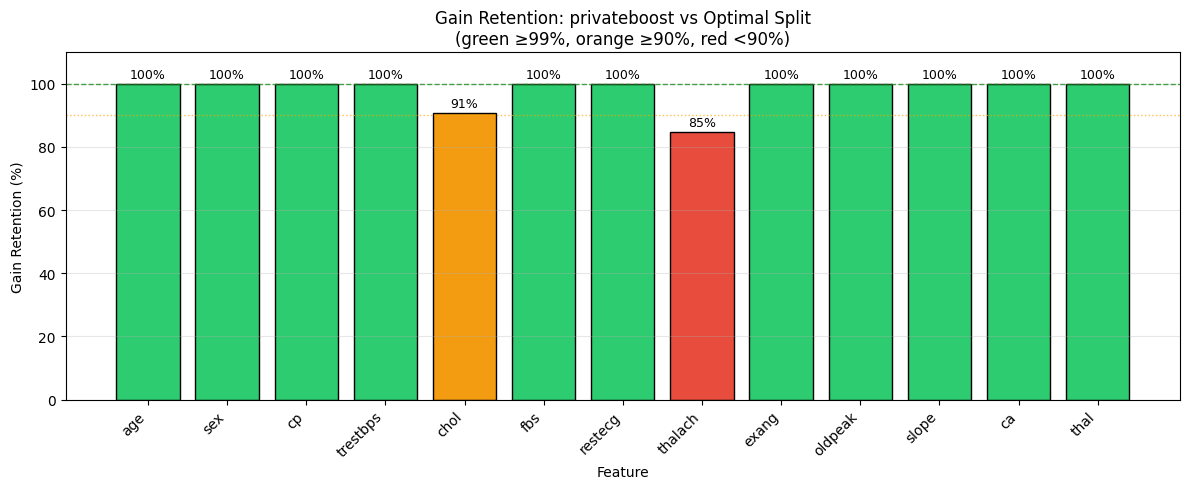


Mean gain retention: 98.1%
Features with ≥99% retention: 11/13


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

features = [r['feature'] for r in results]
retentions = [r['retention'] for r in results]

colors = ['#2ecc71' if r >= 99 else '#f39c12' if r >= 90 else '#e74c3c' for r in retentions]

bars = ax.bar(features, retentions, color=colors, edgecolor='black')

ax.axhline(100, color='green', linestyle='--', alpha=0.7, linewidth=1)
ax.axhline(90, color='orange', linestyle=':', alpha=0.7, linewidth=1)

ax.set_ylabel('Gain Retention (%)')
ax.set_xlabel('Feature')
ax.set_title('Gain Retention: privateboost vs Optimal Split\n(green ≥99%, orange ≥90%, red <90%)')
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

for bar, ret in zip(bars, retentions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{ret:.0f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/gain_retention.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean gain retention: {np.mean(retentions):.1f}%")
print(f"Features with ≥99% retention: {sum(r >= 99 for r in retentions)}/{len(FEATURES)}")